In [ ]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Preprocessing
from sklearn.model_selection import train_test_split
# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeRegressor
# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
df=pd.read_csv('/content/data_csv.csv')

In [ ]:
print(df.head)

<bound method NDFrame.head of       CASE_NO_PATIENT'S  A1  A2  A3  A4  A5  A6  A7  A8  A9  ...  \
0                     1   0   0   0   0   0   0   1   1   0  ...   
1                     2   1   1   0   0   0   1   1   0   0  ...   
2                     3   1   0   0   0   0   0   1   1   0  ...   
3                     4   1   1   1   1   1   1   1   1   1  ...   
4                     5   1   1   0   1   1   1   1   1   1  ...   
...                 ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
1980               1981   0   0   0   0   0   0   0   0   0  ...   
1981               1982   0   0   0   0   0   0   0   0   0  ...   
1982               1983   0   0   0   0   0   0   0   0   0  ...   
1983               1984   0   0   0   0   0   0   0   0   0  ...   
1984               1985   0   0   0   0   0   0   0   0   0  ...   

      Global developmental delay/intellectual disability  \
0                                                   Yes    
1                                

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 28 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   CASE_NO_PATIENT'S                                   1985 non-null   int64  
 1   A1                                                  1985 non-null   int64  
 2   A2                                                  1985 non-null   int64  
 3   A3                                                  1985 non-null   int64  
 4   A4                                                  1985 non-null   int64  
 5   A5                                                  1985 non-null   int64  
 6   A6                                                  1985 non-null   int64  
 7   A7                                                  1985 non-null   int64  
 8   A8                                                  1985 non-null   int64  
 9

In [ ]:
df.shape


(1985, 28)

In [ ]:
#step3:Drop duplicate rows
df=df.drop_duplicates()
print("shape after dropping duplicates:",df.shape)

shape after dropping duplicates: (1985, 28)


In [ ]:
#step4:Handle missing data
#option 1:Drop rows with any missing values
df=df.dropna()
print("Final dataset shape:", df.shape)

Final dataset shape: (1923, 28)


In [ ]:
df.describe()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Social_Responsiveness_Scale,Age_Years,Qchat_10_Score,Childhood Autism Rating Scale
count,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000
mean,990.641706,0.302132,0.241810,0.215289,0.274571,0.279771,0.306292,0.347374,0.246490,0.261050,0.453458,3.141966,9.611024,4.217369,1.712949
std,577.501297,0.459302,0.428291,0.411129,0.446414,0.449003,0.461073,0.476260,0.431079,0.439322,0.497959,3.703518,4.310228,2.895612,1.022013
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,483.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,2.000000,1.000000
50%,984.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,4.000000,1.000000
75%,1493.500000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,6.000000,14.000000,6.000000,2.000000
max,1985.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,18.000000,10.000000,4.000000


In [ ]:
df.columns

Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
CASE_NO_PATIENT'S,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


In [ ]:
duplicates=df.duplicated().sum()
print("duplcates rows:",duplicates)

duplcates rows: 0


In [ ]:
X=df[['A1','A2','A3','A4','A5','A6','A7','A8']]
y=df['A9']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X

,A1,A2,A3,A4,A5,A6,A7,A8
0,0,0,0,0,0,0,1,1
1,1,1,0,0,0,1,1,0
2,1,0,0,0,0,0,1,1
3,1,1,1,1,1,1,1,1
4,1,1,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...
1980,0,0,0,0,0,0,0,0
1981,0,0,0,0,0,0,0,0
1982,0,0,0,0,0,0,0,0
1983,0,0,0,0,0,0,0,0


In [ ]:
y

,A9
0,0
1,0
2,0
3,1
4,1
...,...
1980,0
1981,0
1982,0
1983,0


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1538, 8)
(385, 8)
(1538,)
(385,)


In [ ]:
dt_model = DecisionTreeClassifier(max_depth=3 ,random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f'Mean Squared Error: {mse}')
print(f'R-squared Value: {r2}')

Mean Squared Error: 0.15584415584415584
R-squared Value: 0.15551656064926533


In [ ]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2:", r2_score(y_test, lr_pred))
print("\n")

Accuracy: 0.8649350649350649
MSE: 0.13506493506493505
R2: 0.26811435256269656




In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))
print("\n")

Accuracy: 0.8571428571428571
MSE: 0.14285714285714285
R2: 0.22589018059515986




In [ ]:
# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, knn_pred))
print("MSE:", mean_squared_error(y_test, knn_pred))
print("R2:", r2_score(y_test, knn_pred))

Accuracy: 0.8441558441558441
MSE: 0.15584415584415584
R2: 0.15551656064926533


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical columns (excluding the target 'A9' and any identifier columns)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove 'ASD_traits' as it is highly correlated with 'A9' and 'CASE_NO_PATIENT'S' if it exists
if 'ASD_traits' in categorical_cols:
    categorical_cols.remove('ASD_traits')

# Also remove 'CASE_NO_PATIENT'S' as it's an identifier
if 'CASE_NO_PATIENT\'S' in df.columns:
    df = df.drop(columns=['CASE_NO_PATIENT\'S'])

# Let's verify which columns are now considered categorical for encoding
# We will use all columns except A1-A10 and other numerical columns.
# Re-identifying categorical columns after dropping 'CASE_NO_PATIENT'S'
categorical_features = df.select_dtypes(include='object').columns.tolist()

# Define the preprocessor for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical columns as they are
)

# Apply preprocessing to create the full feature set
X_full = df.drop('A9', axis=1) # Drop target variable from features
y = df['A9'] # Redefine target variable

X_processed = preprocessor.fit_transform(X_full)

# Get feature names after one-hot encoding (useful for model interpretation)
# This part can be tricky with ColumnTransformer, a common approach is below:
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
other_feature_names = [col for col in X_full.columns if col not in categorical_features and col != 'A9']
all_feature_names = list(onehot_feature_names) + other_feature_names

print(f"Original number of features: {X_full.shape[1]}")
print(f"Number of features after one-hot encoding: {X_processed.shape[1]}")
print(f"First 5 feature names after encoding: {all_feature_names[:5]} ...")


Original number of features: 26
Number of features after one-hot encoding: 57
First 5 feature names after encoding: ['Speech Delay/Language Disorder_No', 'Speech Delay/Language Disorder_Yes', 'Learning disorder_No', 'Learning disorder_Yes', 'Genetic_Disorders_No'] ...


In [ ]:
from sklearn.model_selection import train_test_split

X_train_processed, X_test_processed, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train after preprocessing: {X_train_processed.shape}")
print(f"Shape of X_test after preprocessing: {X_test_processed.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train after preprocessing: (1538, 57)
Shape of X_test after preprocessing: (385, 57)
Shape of y_train: (1538,)
Shape of y_test: (385,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# Define the model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20],   # Maximum depth of the tree
    'min_samples_split': [2, 5],   # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]     # Minimum number of samples required to be at a leaf node
}

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_processed, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

# Evaluate the best model on the test set
best_rf_model = grid_search.best_estimator_
y_pred_tuned_rf = best_rf_model.predict(X_test_processed)

print("\nTest Set Accuracy of Tuned Random Forest:", accuracy_score(y_test, y_pred_tuned_rf))
print("\nClassification Report of Tuned Random Forest:\n", classification_report(y_test, y_pred_tuned_rf))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found:  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best cross-validation accuracy:  0.8985870806717712

Test Set Accuracy of Tuned Random Forest: 0.9012987012987013

Classification Report of Tuned Random Forest:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93       284
           1       0.78      0.86      0.82       101

    accuracy                           0.90       385
   macro avg       0.87      0.89      0.88       385
weighted avg       0.91      0.90      0.90       385



In [ ]:
X.columns.values

array(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8'], dtype=object)

In [ ]:
y.iloc[:5]

,A9
0,0
1,0
2,0
3,1
4,1


In [ ]:

def create_model():
 # create model
 model = Sequential()
 model.add(Dense(8, input_dim=X_train.shape[1], kernel_initializer='normal', activation='relu')) # Corrected input_dim
 model.add(Dense(4, kernel_initializer='normal', activation='relu'))
 model.add(Dense(1, activation='sigmoid')) # Corrected output layer for binary classification
#  model.add(Dropout(0.25)) # to avoid overfitting
 adam = Adam(learning_rate=0.001)

 model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy']) # Corrected loss function
 return model

In [ ]:
dl_model = create_model()
print(dl_model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

None


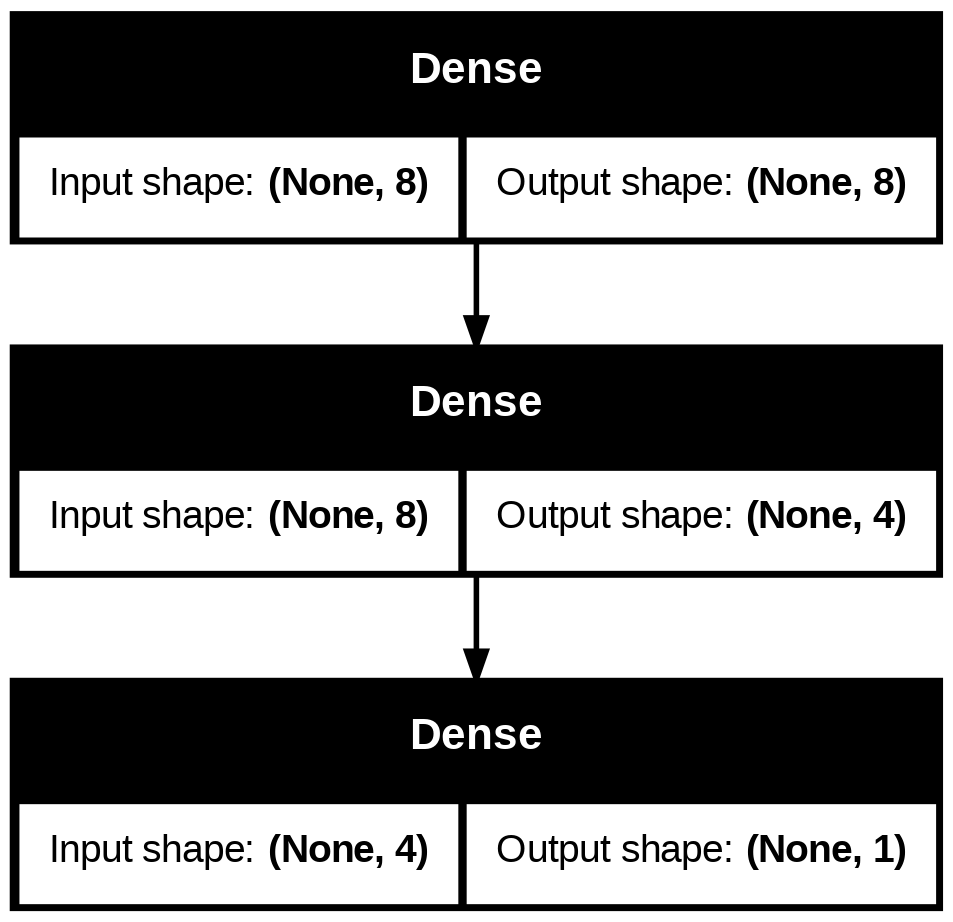

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(dl_model, show_shapes=True, to_file='model.png')

In [ ]:
dl_model.fit(
    X_train, y_train,
    epochs=30, batch_size=32,
    validation_split=0.1,
    verbose=2
)

loss, acc = dl_model.evaluate(X_test, y_test, verbose=0)
print(f"\nDeep Learning Accuracy: {acc:.4f}")

Epoch 1/30
44/44 - 1s - 26ms/step - accuracy: 0.7442 - loss: 0.6785 - val_accuracy: 0.6948 - val_loss: 0.6672
Epoch 2/30
44/44 - 0s - 8ms/step - accuracy: 0.7442 - loss: 0.6383 - val_accuracy: 0.6948 - val_loss: 0.6352
Epoch 3/30
44/44 - 0s - 4ms/step - accuracy: 0.7442 - loss: 0.6017 - val_accuracy: 0.6948 - val_loss: 0.6278
Epoch 4/30
44/44 - 0s - 4ms/step - accuracy: 0.7442 - loss: 0.5877 - val_accuracy: 0.6948 - val_loss: 0.6246
Epoch 5/30
44/44 - 0s - 4ms/step - accuracy: 0.7442 - loss: 0.5818 - val_accuracy: 0.6948 - val_loss: 0.6233
Epoch 6/30
44/44 - 0s - 4ms/step - accuracy: 0.7442 - loss: 0.5761 - val_accuracy: 0.6948 - val_loss: 0.6227
Epoch 7/30
44/44 - 0s - 3ms/step - accuracy: 0.7442 - loss: 0.5726 - val_accuracy: 0.6948 - val_loss: 0.6221
Epoch 8/30
44/44 - 0s - 2ms/step - accuracy: 0.7442 - loss: 0.5703 - val_accuracy: 0.6948 - val_loss: 0.6210
Epoch 9/30
44/44 - 0s - 3ms/step - accuracy: 0.7442 - loss: 0.5685 - val_accuracy: 0.6948 - val_loss: 0.6227
Epoch 10/30
44/44 

In [ ]:
dl_pred = (dl_model.predict(X_test) > 0.5).astype("int32")
dl_mse = mean_squared_error(y_test, dl_pred)
dl_r2 = r2_score(y_test, dl_pred)

print(f"Deep Learning MSE: {dl_mse:.4f}")
print(f"Deep Learning R2: {dl_r2:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Deep Learning MSE: 0.2623
Deep Learning R2: -0.3556


In [ ]:
print('Prediction Results for Neural Network')
print(accuracy_score(y_test, dl_pred))
print(classification_report(y_test, dl_pred))

Prediction Results for Neural Network
0.7376623376623377
              precision    recall  f1-score   support

           0       0.74      1.00      0.85       284
           1       0.00      0.00      0.00       101

    accuracy                           0.74       385
   macro avg       0.37      0.50      0.42       385
weighted avg       0.54      0.74      0.63       385



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


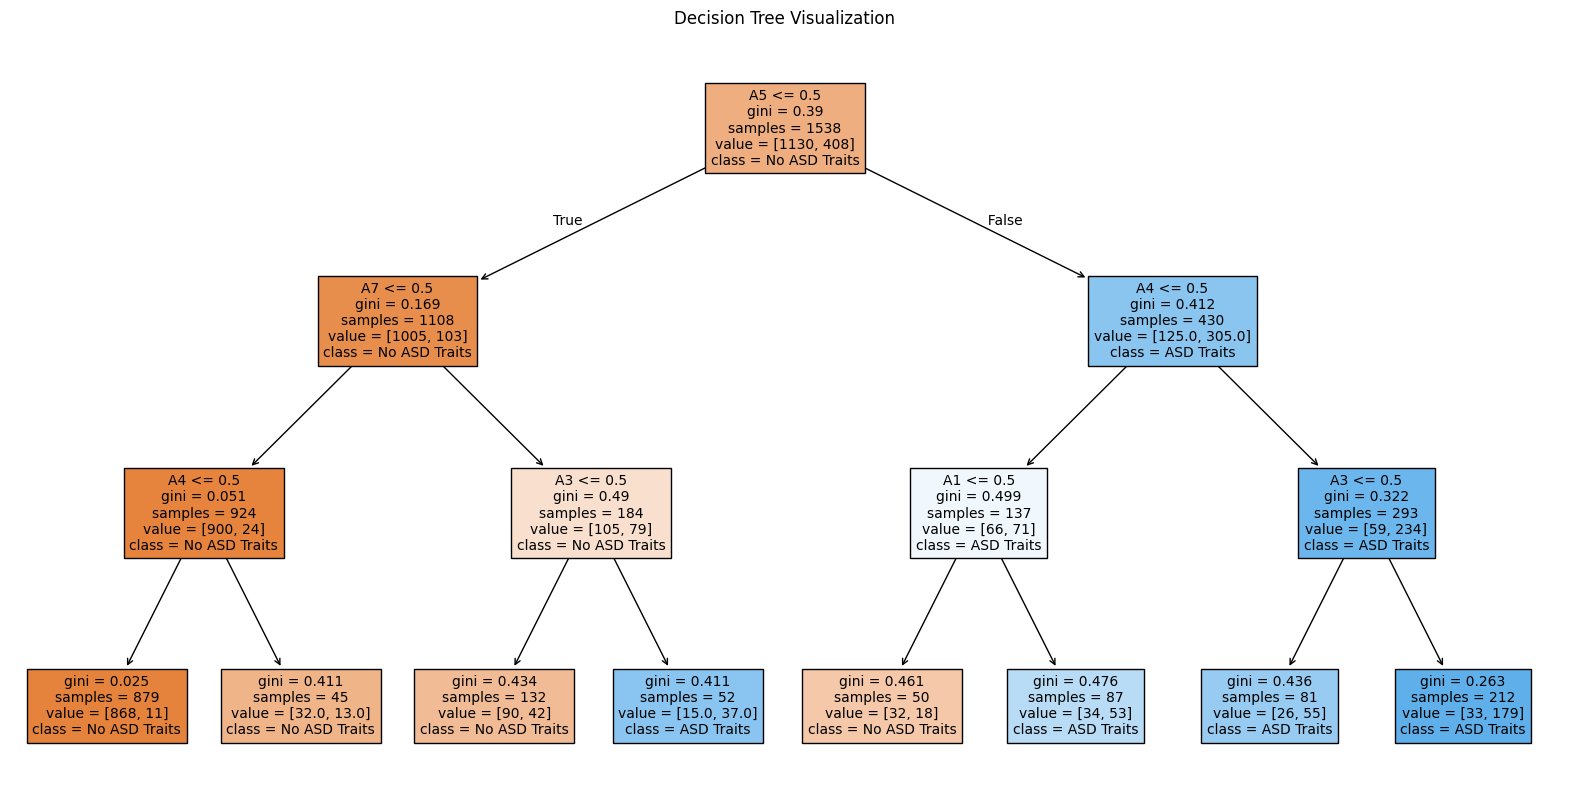

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, feature_names=X.columns.tolist(), class_names=['No ASD Traits', 'ASD Traits'], fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

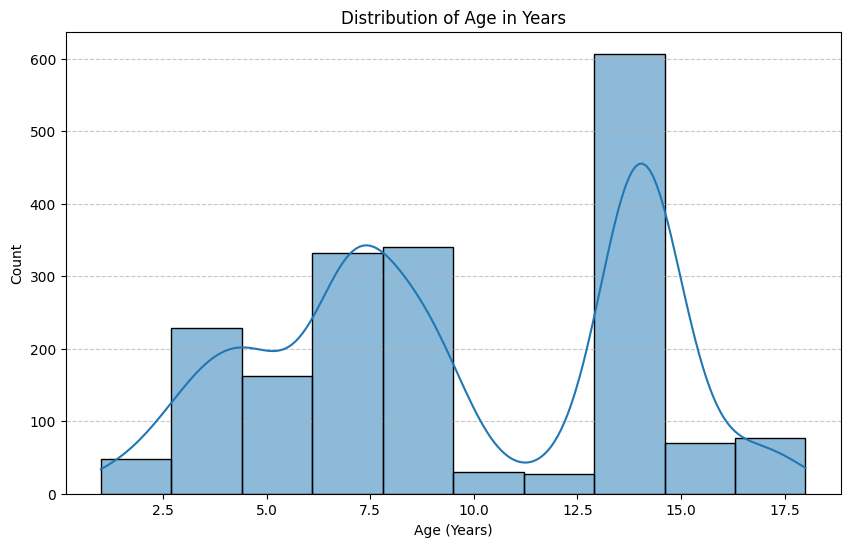

In [ ]:
#Distribution of Age
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Age_Years'], bins=10, kde=True)
plt.title('Distribution of Age in Years')
plt.xlabel('Age (Years)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipython-input-4183300409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='viridis')


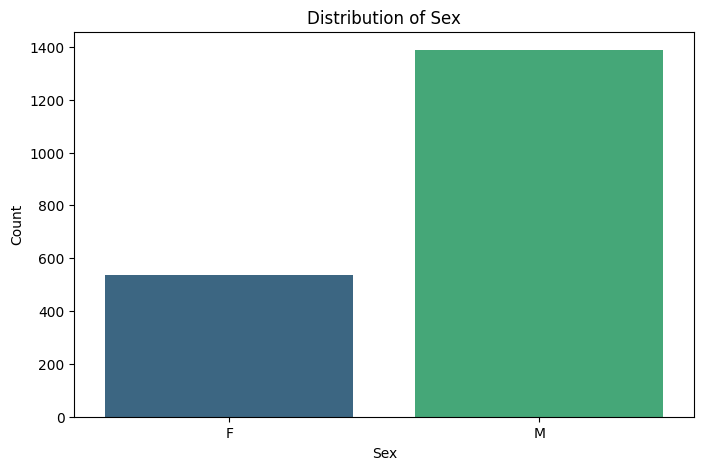

In [ ]:
#Distribution of Sex
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', data=df, palette='viridis')
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()


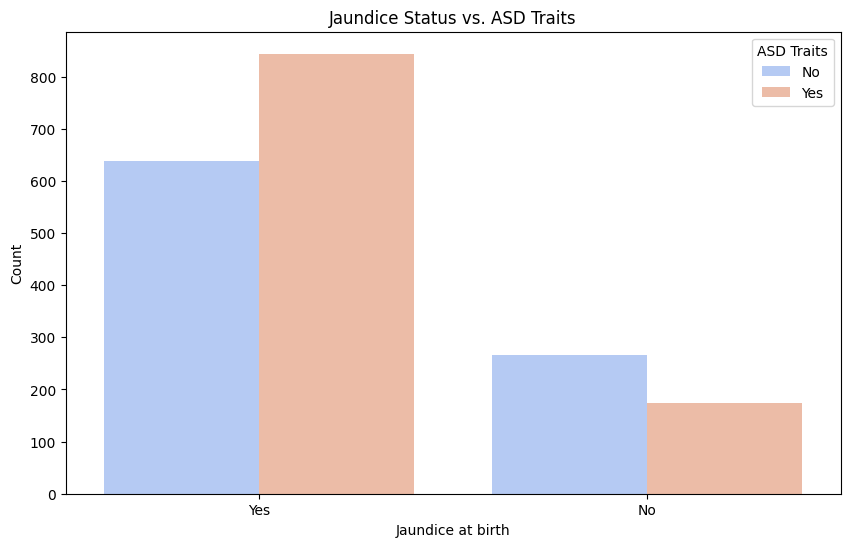

In [ ]:
#Relationship between Jaundice and ASD Traits
plt.figure(figsize=(10, 6))
sns.countplot(x='Jaundice', hue='ASD_traits', data=df, palette='coolwarm')
plt.title('Jaundice Status vs. ASD Traits')
plt.xlabel('Jaundice at birth')
plt.ylabel('Count')
plt.legend(title='ASD Traits')
plt.show()


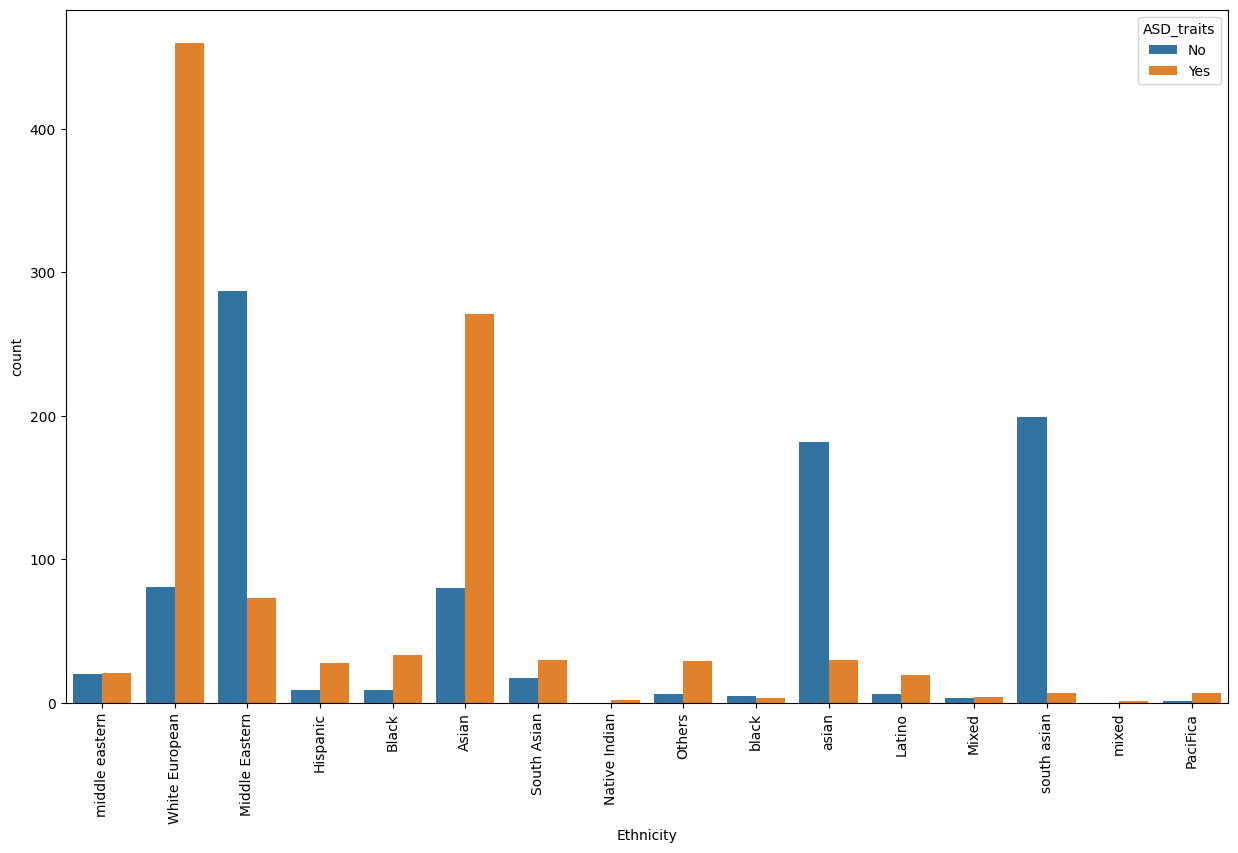

In [ ]:
plt.figure(figsize=(15,9))
sns.countplot(data=df,x='Ethnicity',hue='ASD_traits')
plt.xticks(rotation=90)
plt.show()

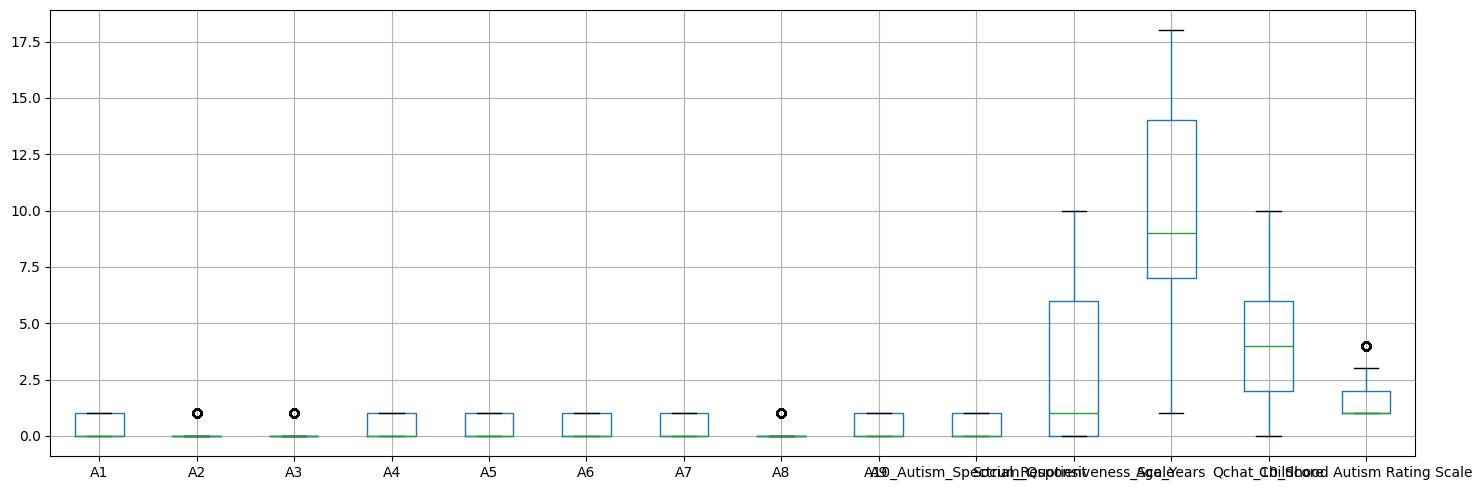

In [ ]:
# check outliers using boxplot
fig,ax=plt.subplots(figsize=(15,5))
df.boxplot(ax=ax)
plt.tight_layout()
plt.show()


In [ ]:
asd_ethnicity = df.groupby('Ethnicity')['ASD_traits'].value_counts(normalize=True).unstack().fillna(0)

asd_ethnicity['ASD_Yes_Percentage'] = asd_ethnicity['Yes'] * 100

lowest_asd_ethnicity = asd_ethnicity.sort_values(by='ASD_Yes_Percentage').head()

print("Ethnicities with the lowest percentage of ASD traits (Top 5):")
display(lowest_asd_ethnicity)

Ethnicities with the lowest percentage of ASD traits (Top 5):


ASD_traits,No,Yes,ASD_Yes_Percentage
Ethnicity,,,
south asian,0.966019,0.033981,3.398058
asian,0.858491,0.141509,14.150943
Middle Eastern,0.797222,0.202778,20.277778
black,0.625000,0.375000,37.500000
middle eastern,0.487805,0.512195,51.219512


In [ ]:
# Install required libraries (run this if not installed)
!pip install ipywidgets tensorflow scikit-learn pandas numpy

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load and preprocess dataset
def load_and_preprocess_data():
    df = pd.read_csv('data_csv.csv')
    df = df.drop(['CASE_NO_PATIENT\'S'], axis=1)

    # Define the list of features that will be used (corresponding to widgets)
    widget_features = [
        'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9',
        'A10_Autism_Spectrum_Quotient', 'Age_Years', 'Qchat_10_Score',
        'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who_completed_the_test'
    ]

    # Filter df to only include these features and the target
    df_filtered = df[widget_features + ['ASD_traits']].copy()

    label_encoders = {}

    # Handle NaNs for numeric columns *before* feature selection if necessary,
    # or ensure widget_features are clean.
    # For simplicity, filling NaNs in relevant numeric columns for filtered df.
    for col in ['Age_Years', 'Qchat_10_Score']: # These are the numeric widget features
        if col in df_filtered.columns:
            df_filtered[col] = df_filtered[col].fillna(df_filtered[col].mean())

    categorical_widget_features = [
        'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who_completed_the_test'
    ]

    for col in categorical_widget_features:
        le = LabelEncoder()
        # Fit on *all unique values* from the column in the filtered dataframe
        df_filtered[col] = le.fit_transform(df_filtered[col])
        label_encoders[col] = le

    X = df_filtered.drop('ASD_traits', axis=1)
    y = df_filtered['ASD_traits'].map({'No': 0, 'Yes': 1})

    feature_columns_for_model = X.columns.tolist() # Store the order of features

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, label_encoders, feature_columns_for_model

# Train the Keras model
def train_model(X_train_scaled, y_train):
    y_train_cat = to_categorical(y_train, 2)
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train_scaled, y_train_cat, epochs=20, batch_size=32, verbose=0)  # Silent
    return model

# Load data and train model
X_train_scaled, X_test_scaled, y_train, y_test, scaler, label_encoders, feature_columns_for_model = load_and_preprocess_data()
model = train_model(X_train_scaled, y_train)

# Create interactive widgets (boxes)
age_widget = widgets.IntSlider(value=25, min=0, max=100, description='Age:')
gender_widget = widgets.Dropdown(options=['M', 'F'], value='M', description='Sex:')
ethnicity_widget = widgets.Dropdown(options=['White European', 'Middle Eastern', 'Hispanic', 'Latino', 'Black', 'Asian', 'South Asian', 'Others', 'Turkish', 'Pasifika', 'Native Indian'], value='White European', description='Ethnicity:')
jaundice_widget = widgets.Dropdown(options=['Yes', 'No'], value='No', description='Jaundice:')
austim_widget = widgets.Dropdown(options=['Yes', 'No'], value='No', description='Family_mem_with_ASD:')
# contry_widget is removed as it's not a feature in the model
relation_widget = widgets.Dropdown(options=['Self', 'Parent', 'Relative', 'Others', 'Health care professional'], value='Self', description='Who_completed_the_test:')
result_widget = widgets.IntSlider(value=5, min=0, max=10, description='Qchat_10_Score:')
a1_widget = widgets.Dropdown(options=[0, 1], value=0, description='A1:')
a2_widget = widgets.Dropdown(options=[0, 1], value=0, description='A2:')
a3_widget = widgets.Dropdown(options=[0, 1], value=0, description='A3:')
a4_widget = widgets.Dropdown(options=[0, 1], value=0, description='A4:')
a5_widget = widgets.Dropdown(options=[0, 1], value=0, description='A5:')
a6_widget = widgets.Dropdown(options=[0, 1], value=0, description='A6:')
a7_widget = widgets.Dropdown(options=[0, 1], value=0, description='A7:')
a8_widget = widgets.Dropdown(options=[0, 1], value=0, description='A8:')
a9_widget = widgets.Dropdown(options=[0, 1], value=0, description='A9:')
a10_widget = widgets.Dropdown(options=[0, 1], value=0, description='A10_Autism_Spectrum_Quotient:')

button = widgets.Button(description="Predict ASD")
output = widgets.Output()

# Prediction function
def predict(b):
    with output:
        clear_output(wait=True)

        input_data_raw = {
            'Age_Years': age_widget.value,
            'Sex': gender_widget.value,
            'Ethnicity': ethnicity_widget.value,
            'Jaundice': jaundice_widget.value,
            'Family_mem_with_ASD': austim_widget.value,
            'Who_completed_the_test': relation_widget.value, # Corrected mapping
            'Qchat_10_Score': result_widget.value,
            'A1': a1_widget.value,
            'A2': a2_widget.value,
            'A3': a3_widget.value,
            'A4': a4_widget.value,
            'A5': a5_widget.value,
            'A6': a6_widget.value,
            'A7': a7_widget.value,
            'A8': a8_widget.value,
            'A9': a9_widget.value,
            'A10_Autism_Spectrum_Quotient': a10_widget.value
        }

        # Create DataFrame from raw input
        input_df = pd.DataFrame([input_data_raw])

        # Ensure the input_df has columns in the same order as trained features
        # This is critical for StandardScaler and model.predict
        input_df = input_df[feature_columns_for_model]

        # Apply stored LabelEncoders
        for col, le in label_encoders.items():
            if col in input_df.columns:
                try:
                    input_df[col] = le.transform(input_df[col])
                except ValueError as e:
                    print(f"Error encoding column '{col}': {e}. Value was '{input_df[col].iloc[0]}'.")
                    raise # Re-raise for debugging during development

        # Scale and predict
        input_scaled = scaler.transform(input_df)
        prediction = model.predict(input_scaled)
        prob_no = prediction[0][0]
        prob_yes = prediction[0][1]
        result = "YES" if prob_yes > 0.5 else "NO"

        print(f"Prediction: {result}")
        print(f"Probability of NO: {prob_no:.2f}")
        print(f"Probability of YES: {prob_yes:.2f}")
        print("Note: This is not a medical diagnosis. Consult a professional.")

button.on_click(predict)

# Display widgets (contry_widget is removed from display as it's not a feature)
display(age_widget, gender_widget, ethnicity_widget, jaundice_widget, austim_widget, relation_widget, result_widget, a1_widget, a2_widget, a3_widget, a4_widget, a5_widget, a6_widget, a7_widget, a8_widget, a9_widget, a10_widget, button, output)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


IntSlider(value=25, description='Age:')

Dropdown(description='Sex:', options=('M', 'F'), value='M')

Dropdown(description='Ethnicity:', options=('White European', 'Middle Eastern', 'Hispanic', 'Latino', 'Black',…

...

Dropdown(description='A8:', options=(0, 1), value=0)

Dropdown(description='A9:', options=(0, 1), value=0)

Dropdown(description='A10_Autism_Spectrum_Quotient:', options=(0, 1), value=0)

Button(description='Predict ASD', style=ButtonStyle())

Output()